In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

Using device: cuda


In [4]:
transform = transforms.Compose(
    [transforms.ToTensor()]
)

train_dataset = datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.28MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 220kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.10MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]


In [ ]:
image, labels = train_dataset[0]
print(image.size())
print(labels)

torch.Size([1, 28, 28])
5


In [6]:
len(train_dataset)

60000

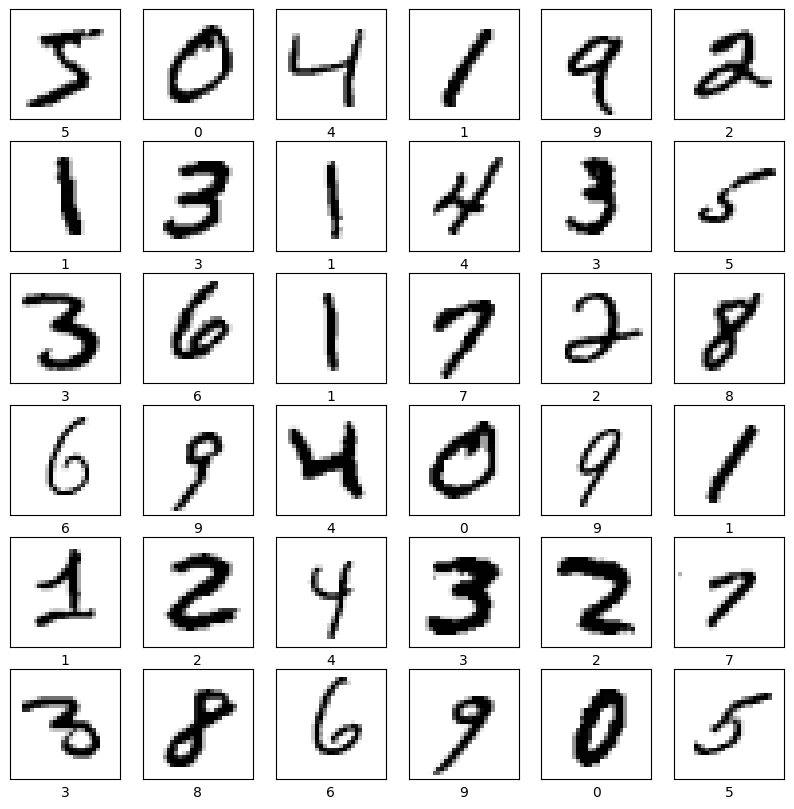

In [ ]:
plt.figure(figsize=(10, 10))
random_ids = np.random.choice(len(train_dataset), 36)

for i in range(36):
    plt.subplot(6, 6, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image_id = random_ids[i]
    image, labels = train_dataset[i]
    plt.imshow(image.squeeze(), cmap=plt.cm.binary)
    plt.xlabel(labels)


In [28]:
class FullyConnectedModel(nn.Module):

    def __init__(self, *args, **kwargs):
        super(FullyConnectedModel, self).__init__(*args, **kwargs)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x


fc_model = FullyConnectedModel().to(device=device)

total_params = sum(p.numel() for p in fc_model.parameters() if p.requires_grad)
print(f"Total number of parameters: {total_params}")

Total number of parameters: 101770


In [ ]:
image, labels = train_dataset[0]
fc_model(image.to(device))

tensor([[-0.1175, -0.0285,  0.1090,  0.1067,  0.1033, -0.0145,  0.0424,  0.1132,
          0.1221, -0.1019]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [38]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(fc_model.parameters(), lr=0.01)

In [39]:
BATCH_SIZE = 64
trainset_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True)
testset_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [40]:
def train(model: nn.Module, dataloader: DataLoader, criterion: nn.CrossEntropyLoss, optimizer: optim.Optimizer, epochs: int):
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        corrected_pred = 0
        total_pred = 0

        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            optimizer.zero_grad()
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()*images.size(0)

            predicted = torch.argmax(outputs, dim=1)
            corrected_pred += (predicted == labels).sum().item()
            total_pred += labels.size(0)

        total_epoch_loss = total_loss / total_pred
        epoch_accuracy = corrected_pred / total_pred
        print(
            f"Epoch {epoch + 1}, Loss: {total_epoch_loss}, Accuracy: {epoch_accuracy: .4f}")

In [41]:
EPOCHS = 5
train(
    model=fc_model,
    dataloader=trainset_loader,
    criterion=loss_function,
    optimizer=optimizer,
    epochs=EPOCHS
)

Epoch 1, Loss: 1.2670417305628459, Accuracy:  0.7335
Epoch 2, Loss: 0.5025461695512136, Accuracy:  0.8732
Epoch 3, Loss: 0.396885430876414, Accuracy:  0.8918
Epoch 4, Loss: 0.3554316442012787, Accuracy:  0.9002
Epoch 5, Loss: 0.33035221028327943, Accuracy:  0.9062


In [63]:
def evaluate(model: nn.Module, dataloader: DataLoader, loss_function: nn.CrossEntropyLoss):
    model.eval()
    test_loss = 0
    correct_pred = 0
    total_pred = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = loss_function(outputs, labels)
            test_loss += loss.item() * images.size(0)

            prediction = torch.argmax(outputs, dim=1)
            correct_pred += (prediction == labels).sum().item()
            total_pred += labels.size(0)

    test_loss /= total_pred
    test_acc = correct_pred / total_pred
    return test_loss, test_acc

In [64]:
test_loss, test_acc = evaluate(
    model=fc_model,
    dataloader=testset_loader,
    loss_function=loss_function
)

print(f"Test loss: {test_loss:.5f}\tTest accuracy: {test_acc:.5f}")

Test loss: 0.30515	Test accuracy: 0.91440


Convolutional

In [58]:
class CNN(nn.Module):
    def __init__(self, *args, **kwargs):
        super(CNN, self).__init__(*args, **kwargs)

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=24, kernel_size=3)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=24, out_channels=36, kernel_size=3)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(36*5*5, 128)
        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

In [59]:
cnn_model = CNN().to(device=device)

total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Total number of parameters: {total_params}")

Total number of parameters: 124670


CNN expects (batch, channels, height, width)

In [60]:
image, label = train_dataset[0]
print(f"Image shape before: {image.shape}")
# The operation below adds a batch dimension
image = image.to(device).unsqueeze(0)
print(f"Image shape after: {image.shape}")
cnn_model(image)

Image shape before: torch.Size([1, 28, 28])
Image shape after: torch.Size([1, 1, 28, 28])


tensor([[-0.0423,  0.0828,  0.0030, -0.0704, -0.0460, -0.0131, -0.0281,  0.0155,
         -0.0636,  0.0286]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [61]:
BATCH_SIZE=64
EPOCHS=5
optimizer = optim.SGD(cnn_model.parameters(), lr=1e-2)
loss_function = nn.CrossEntropyLoss()

In [62]:
train(
    model=cnn_model,
    dataloader=trainset_loader,
    criterion=loss_function,
    optimizer=optimizer,
    epochs=EPOCHS
)

Epoch 1, Loss: 1.2992263326644897, Accuracy:  0.6226
Epoch 2, Loss: 0.32708322562376657, Accuracy:  0.9005
Epoch 3, Loss: 0.2205111518383026, Accuracy:  0.9329
Epoch 4, Loss: 0.16451670476992925, Accuracy:  0.9495
Epoch 5, Loss: 0.1310971233636141, Accuracy:  0.9603


In [65]:
test_loss, test_acc = evaluate(
    model=cnn_model,
    dataloader=testset_loader,
    loss_function=loss_function
)

print(f"Test loss: {test_loss:.5f}\tTest Accuracy: {test_acc:.5f}")

Test loss: 0.10734	Test Accuracy: 0.96780


In [73]:
image, label = train_dataset[0]
image = image.to(device).unsqueeze(0)
logits = cnn_model(image)
nn.functional.softmax(logits, dim=1)

tensor([[3.1319e-06, 3.4649e-05, 8.2602e-04, 4.3498e-01, 1.8279e-09, 5.6402e-01,
         3.0580e-08, 2.9299e-05, 9.9432e-05, 3.6689e-06]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)

In [79]:
torch.argmax(logits), nn.functional.softmax(logits, dim=1).max()

(tensor(5, device='cuda:0'),
 tensor(0.5640, device='cuda:0', grad_fn=<MaxBackward1>))

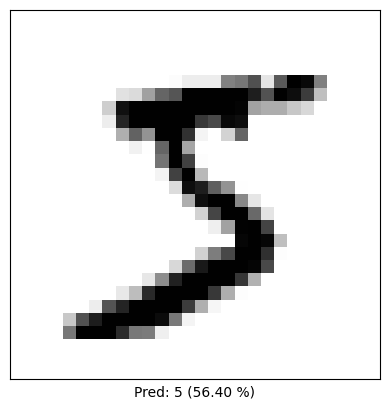

In [ ]:
plt.figure()
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.imshow(image.to('cpu').squeeze(), cmap=plt.cm.binary)
plt.xlabel(
    f"Pred: {torch.argmax(logits).item()} ({nn.functional.softmax(logits, dim=1).max().item()*100:.2f} %)")

plt.show()